In [4]:
import networkx as nx 
import pandas as pd 
import numpy as np 
from tqdm import tqdm

In [5]:
from pathlib import Path
import yaml

CONFIG_PATH = Path("../workflow/config.yaml")

with CONFIG_PATH.open("r") as f:
    config = yaml.safe_load(f)

RESULTS = Path(config["results_dir"])
GROUP_DISTANCE = RESULTS / "distances" / "group_ppr_distance.csv"

In [6]:
group = pd.read_csv(GROUP_DISTANCE, index_col=0)
group

,euclidean,jensen_shannon,cosine_distance,cosine_similarity
month,,,,
201508,0.105862,0.558112,0.207052,0.792948
201509,0.098269,0.621297,0.254618,0.745382
201510,0.103376,0.623661,0.263803,0.736197
201511,0.100083,0.630730,0.266860,0.733140
201512,0.106284,0.656854,0.342019,0.657981
201601,0.089400,0.623129,0.217561,0.782439
201602,0.089737,0.640816,0.262816,0.737184
201603,0.059324,0.640601,0.154588,0.845412
201604,0.056718,0.653118,0.161761,0.838239


### Statistical Tests

In [7]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# group:
# index = month (e.g., 201508, ..., 201612)
# columns = euclidean, cosine_distance, ...

its_df = group.reset_index().copy()
its_df["month"] = its_df["month"].astype(str)

# Exclude July 2016 event month
its_df = (
    its_df[its_df["month"] != "201607"]
    .reset_index(drop=True)
)

its_df["time"] = np.arange(len(its_df))

post_start = its_df.index[
    its_df["month"] == "201608"
][0]

its_df["post"] = (
    its_df["month"] >= "201608"
).astype(int)

its_df["time_after"] = np.where(
    its_df["time"] >= post_start,
    its_df["time"] - post_start + 1,
    0
)

its_df[
    [
        "month",
        "time",
        "post",
        "time_after",
        "euclidean",
        "cosine_distance",
    ]
]

,month,time,post,time_after,euclidean,cosine_distance
0,201508,0,0,0,0.105862,0.207052
1,201509,1,0,0,0.098269,0.254618
2,201510,2,0,0,0.103376,0.263803
3,201511,3,0,0,0.100083,0.266860
4,201512,4,0,0,0.106284,0.342019
5,201601,5,0,0,0.089400,0.217561
6,201602,6,0,0,0.089737,0.262816
7,201603,7,0,0,0.059324,0.154588
8,201604,8,0,0,0.056718,0.161761
9,201605,9,0,0,0.086176,0.071353


In [ ]:
its_models = {}

for outcome in ["euclidean", "cosine_distance"]:

    model = smf.ols(
        f"{outcome} ~ time + post + time_after",
        data=its_df
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 1}
    )

    its_models[outcome] = model

    print("=" * 80)
    print(outcome)
    print(model.summary())

In [9]:
for outcome, model in its_models.items():

    post_slope_test = model.t_test(
        "time + time_after = 0"
    )

    print(f"\n{outcome}")
    print("Post-fork slope test:")
    print(post_slope_test)


euclidean
Post-fork slope test:
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0072      0.001    -13.917      0.000      -0.008      -0.006

cosine_distance
Post-fork slope test:
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0023      0.014      0.157      0.875      -0.026       0.031


In [10]:
its_results = []

for outcome, model in its_models.items():

    for term in ["time", "post", "time_after"]:
        its_results.append({
            "outcome": outcome,
            "term": term,
            "coef": model.params[term],
            "se_hac": model.bse[term],
            "p_value": model.pvalues[term],
            "ci_lower": model.conf_int().loc[term, 0],
            "ci_upper": model.conf_int().loc[term, 1],
        })

its_results = pd.DataFrame(its_results)
its_results

,outcome,term,coef,se_hac,p_value,ci_lower,ci_upper
0,euclidean,time,-0.005981,0.001160,2.508020e-07,-0.008254,-0.003708
1,euclidean,post,0.047006,0.008686,6.238904e-08,0.029982,0.064030
2,euclidean,time_after,-0.001172,0.001018,2.498912e-01,-0.003167,0.000824
3,cosine_distance,time,-0.018465,0.006108,2.503467e-03,-0.030437,-0.006493
4,cosine_distance,post,0.221392,0.051590,1.776075e-05,0.120276,0.322507
5,cosine_distance,time_after,0.020734,0.016439,2.072086e-01,-0.011486,0.052954


In [11]:
from itertools import combinations
import numpy as np
import pandas as pd

perm_df = its_df[
    its_df["month"] != "201607"
].copy()

perm_df["period"] = np.where(
    perm_df["month"] <= "201606",
    "pre",
    "post"
)

perm_results = []

for outcome in ["euclidean", "cosine_distance"]:

    values = perm_df[outcome].to_numpy(dtype=float)

    pre_mask = perm_df["period"].eq("pre").to_numpy()
    post_mask = perm_df["period"].eq("post").to_numpy()

    n_total = len(values)
    n_post = post_mask.sum()

    observed_diff = (
        values[post_mask].mean()
        - values[pre_mask].mean()
    )

    perm_diffs = []

    all_indices = np.arange(n_total)

    for post_indices in combinations(all_indices, n_post):

        perm_post_mask = np.zeros(
            n_total,
            dtype=bool
        )
        perm_post_mask[list(post_indices)] = True

        perm_pre_mask = ~perm_post_mask

        perm_diff = (
            values[perm_post_mask].mean()
            - values[perm_pre_mask].mean()
        )

        perm_diffs.append(perm_diff)

    perm_diffs = np.asarray(perm_diffs)

    # Two-sided exact p-value
    p_value = np.mean(
        np.abs(perm_diffs)
        >= np.abs(observed_diff)
    )

    perm_results.append({
        "outcome": outcome,
        "pre_mean": values[pre_mask].mean(),
        "post_mean": values[post_mask].mean(),
        "mean_difference_post_minus_pre": observed_diff,
        "exact_permutation_p": p_value,
        "n_pre": pre_mask.sum(),
        "n_post": post_mask.sum(),
        "n_permutations": len(perm_diffs),
    })

perm_results = pd.DataFrame(perm_results)
perm_results

,outcome,pre_mean,post_mean,mean_difference_post_minus_pre,exact_permutation_p,n_pre,n_post,n_permutations
0,euclidean,0.084253,0.079895,-0.004358,0.721612,11,5,4368
1,cosine_distance,0.206531,0.342405,0.135874,0.006639,11,5,4368


In [12]:
effect_size_results = []

for outcome in ["euclidean", "cosine_distance"]:

    pre = perm_df.loc[
        perm_df["period"] == "pre",
        outcome
    ].to_numpy()

    post = perm_df.loc[
        perm_df["period"] == "post",
        outcome
    ].to_numpy()

    pooled_sd = np.sqrt(
        (
            (len(pre) - 1) * pre.var(ddof=1)
            + (len(post) - 1) * post.var(ddof=1)
        )
        / (len(pre) + len(post) - 2)
    )

    cohens_d = (
        post.mean() - pre.mean()
    ) / pooled_sd

    effect_size_results.append({
        "outcome": outcome,
        "cohens_d": cohens_d
    })

pd.DataFrame(effect_size_results)

,outcome,cohens_d
0,euclidean,-0.201935
1,cosine_distance,1.755826


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


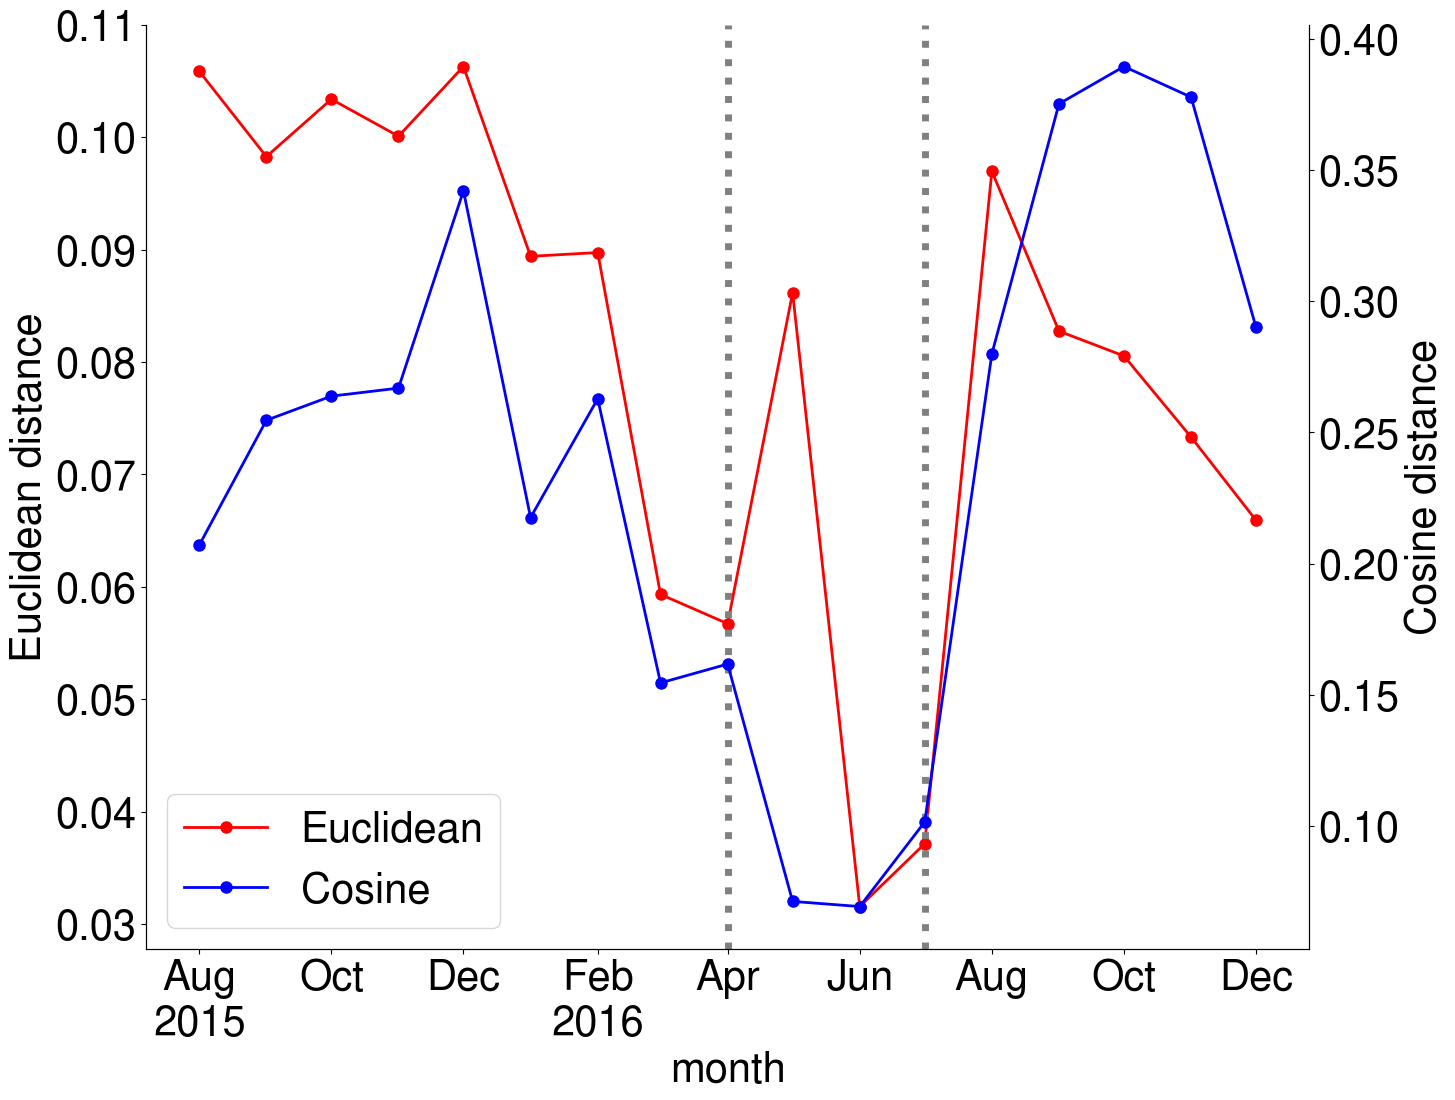

In [13]:
# monthly index 
month_idx = pd.date_range(start='08/01/2015', end='12/01/2016', freq='MS', tz='UTC') 
month_idx_str = [m.strftime('%Y%m') for m in month_idx]

showdate = month_idx[[0,2,4,6,8,10,12,14,16]]
# showmonth = np.array(month_idx)[[0,2,4,6,8,10,12,14,16]]
# xticks = np.array(month_idx_str)[[0,2,4,6,8,10,12,14,16]]

import matplotlib.pyplot as plt 

plt.rcParams["figure.figsize"] = (15, 12)
# plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Nimbus Sans"]
plt.rcParams["font.size"] = 30
plt.rc('xtick', labelsize=30)
plt.rc('ytick', labelsize=30)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()


similarity = [group['euclidean'], group['cosine_distance']]
labels = ["Euclidean", "Cosine"]
colors = ["r", "b", "k"]

for i, ax in enumerate([ax1, ax2]):
    line = ax.plot(month_idx, similarity[i], marker="o", markersize=8, linewidth=2, color=colors[i], label=labels[i])
#     ax.tick_params(axis='x', labelrotation=45)
    ax.spines['top'].set_visible(False)

    ax.set_xticks(showdate)
    ax.set_xticklabels([ts.strftime('%b\n%Y') if ts.year != showdate[idx-1].year
                else ts.strftime('%b') for idx, ts in enumerate(showdate)])
    
    ax.set_ylabel(labels[i] + ' distance')
    ax.set_xlabel('month')

ax1.axvline(x=month_idx[8], color='gray', linestyle=':', linewidth=5)
ax1.axvline(x=month_idx[11], color='gray', linestyle=':', linewidth=5)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(lines + lines2, labels + labels2, loc='lower left')

plt.savefig("../figures/distance_measure.pdf", format="eps", bbox_inches='tight', dpi=200)

In [4]:
import numpy as np
import pandas as pd
import networkx as nx

results = "/data01/storage_damini/Ethereum_publish"

month_idx = pd.date_range(start="08/01/2015", end="12/01/2016", freq="MS", tz="UTC")
month_idx_str = [m.strftime("%Y%m") for m in month_idx]
showdate = month_idx[[0, 2, 4, 6, 8, 10, 12, 14, 16]]

group = pd.read_csv(f"{results}/distances/group_ppr_distance.csv")

def read_group_ppr(path, name):
    z = np.load(path, allow_pickle=True)

    values = np.asarray(z["ppr"]).ravel()
    nodes = np.asarray(z["nodes"]).astype(str).ravel()

    if len(values) != len(nodes):
        raise ValueError(
            f"Length mismatch: {len(values)} PPR values vs {len(nodes)} nodes"
        )

    return pd.DataFrame(
        {name: values},
        index=nodes
    )

def build_group_ppr_plotdf(month):
    G = nx.read_gexf(
        f"{results}/networks/month={month}/network.gexf"
    )

    pagerankdf = pd.concat(
        [
            read_group_ppr(
                f"{results}/ppr/group/month={month}/type=miner.npz",
                "Miner"
            ),
            read_group_ppr(
                f"{results}/ppr/group/month={month}/type=genesis.npz",
                "Genesis"
            ),
        ],
        axis=1
    )

    pagerankdf.index = pagerankdf.index.astype(str)

    node_type_df = pd.DataFrame(
        index=pd.Index(
            [str(node) for node in G.nodes()],
            name="node"
        )
    )

    node_type_df["type"] = "None"

    node_type_list = [
        "genesis",
        "miner",
        "Exchange",
        "Token Contract",
        "ICO",
    ]

    for label in node_type_list:
        labeled_nodes = [
            str(node)
            for node, attrs in G.nodes(data=True)
            if attrs.get(label) in (1, "1", True)
        ]

        node_type_df.loc[
            node_type_df.index.intersection(labeled_nodes),
            "type"
        ] = label

    pagerankdf = pagerankdf.join(
        node_type_df,
        how="left"
    )

    pagerankdf["type"] = pagerankdf["type"].fillna("None")

    plotdf = (
        pagerankdf
        .rename_axis("node")
        .reset_index()
        .melt(
            id_vars=["node", "type"],
            value_vars=["Miner", "Genesis"],
            var_name="source_group",
            value_name="ppr"
        )
    )

    plotdf["month"] = str(month)

    return plotdf

ppr_plotdf_by_month = {
    month: build_group_ppr_plotdf(month)
    for month in ["201606", "201608"]
}

### Statistical Tests 2

In [7]:
ppr_test_df = pd.concat(
    [
        ppr_plotdf_by_month["201606"],
        ppr_plotdf_by_month["201608"],
    ],
    ignore_index=True
)

ppr_test_df["month"] = pd.Categorical(
    ppr_test_df["month"],
    categories=["201606", "201608"],
    ordered=True,
)

ppr_test_df["source_group"] = pd.Categorical(
    ppr_test_df["source_group"],
    categories=["Miner", "Genesis"],
)

type_order = [
    "genesis",
    "miner",
    "Exchange",
    "Token Contract",
    "ICO",
    "None",
]

ppr_test_df["type"] = pd.Categorical(
    ppr_test_df["type"],
    categories=type_order,
)

# PPR is highly skewed
epsilon = 1e-15

ppr_test_df["log_ppr"] = np.log(
    ppr_test_df["ppr"].clip(lower=0) + epsilon
)

ppr_test_df[
    ["node", "month", "source_group", "type", "ppr", "log_ppr"]
].head()

,node,month,source_group,type,ppr,log_ppr
0,1,201606,Miner,genesis,9.124900e-06,-11.604504
1,1000,201606,Miner,genesis,0.000000e+00,-34.538776
2,100003,201606,Miner,None,5.481562e-08,-16.719290
3,100005,201606,Miner,None,2.370669e-06,-12.952338
4,100006,201606,Miner,None,2.083339e-06,-13.081538


In [ ]:
import statsmodels.formula.api as smf

ppr_model = smf.ols(
    """
    log_ppr
    ~ C(month)
    * C(source_group)
    * C(type)
    """,
    data=ppr_test_df,
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": ppr_test_df["node"]
    },
)

print(ppr_model.summary())

In [9]:
three_way_terms = [
    name
    for name in ppr_model.params.index
    if (
        "C(month)" in name
        and "C(source_group)" in name
        and "C(type)" in name
    )
]

three_way_terms

['C(month)[T.201608]:C(source_group)[T.Genesis]:C(type)[T.miner]',
 'C(month)[T.201608]:C(source_group)[T.Genesis]:C(type)[T.Exchange]',
 'C(month)[T.201608]:C(source_group)[T.Genesis]:C(type)[T.Token Contract]',
 'C(month)[T.201608]:C(source_group)[T.Genesis]:C(type)[T.ICO]',
 'C(month)[T.201608]:C(source_group)[T.Genesis]:C(type)[T.None]']

In [10]:
hypotheses = [
    f"{term} = 0"
    for term in three_way_terms
]

three_way_test = ppr_model.f_test(hypotheses)

print(three_way_test)

<F test: F=13271.713526224365, p=0.0, df_denom=1.98e+05, df_num=5>


In [11]:
target_models = {}
target_results = []

interaction_term = (
    "C(month)[T.201608]:"
    "C(source_group)[T.Genesis]"
)

for target_type in type_order:

    test = ppr_test_df[
        ppr_test_df["type"] == target_type
    ].copy()

    n_rows = len(test)
    n_nodes = test["node"].nunique()
    n_months = test["month"].nunique()
    n_groups = test["source_group"].nunique()

    # Interaction을 추정할 최소 조건
    if (
        n_nodes < 2
        or n_months < 2
        or n_groups < 2
    ):
        target_results.append({
            "type": target_type,
            "n_rows": n_rows,
            "n_nodes": n_nodes,
            "interaction_coef": np.nan,
            "cluster_se": np.nan,
            "p_value": np.nan,
            "status": "Insufficient clusters or variation",
        })
        continue

    model = smf.ols(
        "log_ppr ~ C(month) * C(source_group)",
        data=test,
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": test["node"],
            "use_correction": True,
        },
    )

    target_models[target_type] = model

    target_results.append({
        "type": target_type,
        "n_rows": n_rows,
        "n_nodes": n_nodes,
        "interaction_coef": model.params.get(
            interaction_term,
            np.nan,
        ),
        "cluster_se": model.bse.get(
            interaction_term,
            np.nan,
        ),
        "p_value": model.pvalues.get(
            interaction_term,
            np.nan,
        ),
        "status": "Estimated",
    })

target_results = pd.DataFrame(target_results)

target_results

,type,n_rows,n_nodes,interaction_coef,cluster_se,p_value,status
0,genesis,3676,1591,3.500452,0.349074,1.150206e-23,Estimated
1,miner,2690,951,-2.395108,0.378305,2.433192e-10,Estimated
2,Exchange,86,28,-2.229377,0.992095,2.463110e-02,Estimated
3,Token Contract,4,1,NaN,NaN,NaN,Insufficient clusters or variation
4,ICO,4,2,NaN,NaN,NaN,Insufficient clusters or variation
5,None,447080,194942,-1.527535,0.031553,0.000000e+00,Estimated


In [12]:
from statsmodels.stats.multitest import multipletests

valid = target_results["p_value"].notna()

reject, p_holm, _, _ = multipletests(
    target_results.loc[valid, "p_value"],
    method="holm"
)

target_results.loc[valid, "p_holm"] = p_holm
target_results.loc[valid, "significant_holm"] = reject

target_results

,type,n_rows,n_nodes,interaction_coef,cluster_se,p_value,status,p_holm,significant_holm
0,genesis,3676,1591,3.500452,0.349074,1.150206e-23,Estimated,3.450618e-23,True
1,miner,2690,951,-2.395108,0.378305,2.433192e-10,Estimated,4.866383e-10,True
2,Exchange,86,28,-2.229377,0.992095,2.463110e-02,Estimated,2.463110e-02,True
3,Token Contract,4,1,NaN,NaN,NaN,Insufficient clusters or variation,NaN,NaN
4,ICO,4,2,NaN,NaN,NaN,Insufficient clusters or variation,NaN,NaN
5,None,447080,194942,-1.527535,0.031553,0.000000e+00,Estimated,0.000000e+00,True


In [13]:
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

rng = np.random.default_rng(42)

type_order = [
    "genesis",
    "miner",
    "Exchange",
    "Token Contract",
    "ICO",
    "None",
]

months = ["201606", "201608"]

epsilon = 1e-15
n_permutations = 10000

within_month_results = []



for month in months:

    month_df = ppr_test_df[
        ppr_test_df["month"].astype(str) == month
    ].copy()

    for target_type in type_order:

        test = month_df[
            month_df["type"].astype(str) == target_type
        ].copy()

        # 동일 target node별 Miner/Genesis PPR를 한 행으로 정렬
        paired = (
            test.pivot_table(
                index="node",
                columns="source_group",
                values="ppr",
                aggfunc="first",
            )
        )

        print(paired.columns)

        n_pairs = len(paired)

        if n_pairs < 3:
            within_month_results.append({
                "month": month,
                "type": target_type,
                "n_pairs": n_pairs,
                "mean_log_difference": np.nan,
                "median_log_difference": np.nan,
                "p_value": np.nan,
                "status": "Insufficient paired nodes",
            })
            continue

        miner_log = np.log(
            paired["Miner"].to_numpy(dtype=float) + epsilon
        )

        genesis_log = np.log(
            paired["Genesis"].to_numpy(dtype=float) + epsilon
        )

        # Genesis minus Miner
        differences = genesis_log - miner_log
        observed = differences.mean()

        # Paired sign-flip permutation
        permuted_statistics = np.empty(n_permutations)

        for b in range(n_permutations):
            signs = rng.choice(
                [-1, 1],
                size=n_pairs,
                replace=True,
            )

            permuted_statistics[b] = np.mean(
                differences * signs
            )

        # Two-sided permutation p-value
        p_value = (
            np.sum(
                np.abs(permuted_statistics)
                >= np.abs(observed)
            )
            + 1
        ) / (n_permutations + 1)

        within_month_results.append({
            "month": month,
            "type": target_type,
            "n_pairs": n_pairs,
            "mean_log_difference": observed,
            "median_log_difference": np.median(differences),
            "p_value": p_value,
            "status": "Estimated",
        })

within_month_results = pd.DataFrame(
    within_month_results
)

CategoricalIndex(['Miner', 'Genesis'], categories=['Miner', 'Genesis'], ordered=False, dtype='category', name='source_group')
CategoricalIndex(['Miner', 'Genesis'], categories=['Miner', 'Genesis'], ordered=False, dtype='category', name='source_group')
CategoricalIndex(['Miner', 'Genesis'], categories=['Miner', 'Genesis'], ordered=False, dtype='category', name='source_group')
CategoricalIndex(['Miner', 'Genesis'], categories=['Miner', 'Genesis'], ordered=False, dtype='category', name='source_group')
CategoricalIndex([], categories=['Miner', 'Genesis'], ordered=False, dtype='category', name='source_group')
CategoricalIndex(['Miner', 'Genesis'], categories=['Miner', 'Genesis'], ordered=False, dtype='category', name='source_group')
CategoricalIndex(['Miner', 'Genesis'], categories=['Miner', 'Genesis'], ordered=False, dtype='category', name='source_group')
CategoricalIndex(['Miner', 'Genesis'], categories=['Miner', 'Genesis'], ordered=False, dtype='category', name='source_group')
Categorica

In [14]:
from statsmodels.stats.multitest import multipletests

within_month_results["p_holm"] = np.nan
within_month_results["significant_holm"] = False

for month in ["201606", "201608"]:
    mask = (
        within_month_results["month"].eq(month)
        & within_month_results["p_value"].notna()
    )

    reject, p_adj, _, _ = multipletests(
        within_month_results.loc[mask, "p_value"],
        method="holm"
    )

    within_month_results.loc[mask, "p_holm"] = p_adj
    within_month_results.loc[mask, "significant_holm"] = reject

In [15]:
def p_to_star(p):
    if pd.isna(p):
        return "n.t."
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."

within_month_results["significance"] = (
    within_month_results["p_holm"]
    .apply(p_to_star)
)

In [78]:
month = "201608"

G = nx.read_gexf(
    f"{results}/networks/month={month}/network.gexf"
)

token_nodes = [
    str(node)
    for node, attrs in G.nodes(data=True)
    if attrs.get("Token Contract") in (1, "1", True)
]

print(token_nodes)

['280138']


In [80]:
ppr_plotdf_by_month["201608"].query(
    "type == 'Token Contract'"
)[["source_group", "ppr"]]

,source_group,ppr
24204,Miner,9.560876e-08
136691,Genesis,7.089375e-05


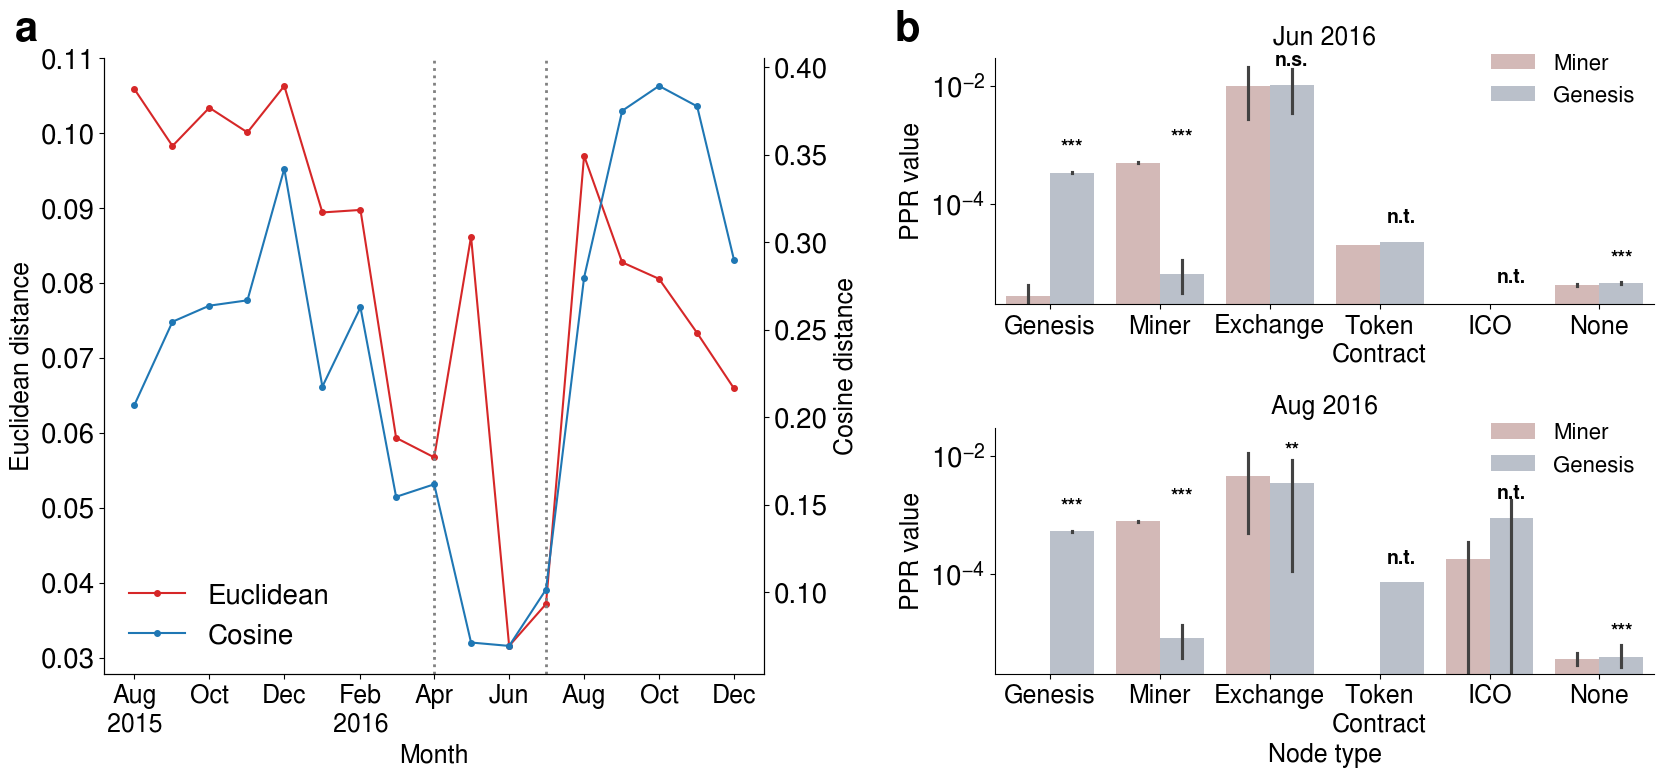

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Nimbus Sans", "Arial", "DejaVu Sans"],
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

fig = plt.figure(figsize=(20, 8))

gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[1, 1],
    hspace=0.5,
    wspace=0.35,
)

# ============================================================
# Panel a: distance time series
# ============================================================

ax1 = fig.add_subplot(gs[:, 0])
ax2 = ax1.twinx()

line1 = ax1.plot(
    month_idx,
    group["euclidean"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    color="tab:red",
    label="Euclidean",
)

line2 = ax2.plot(
    month_idx,
    group["cosine_distance"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    color="tab:blue",
    label="Cosine",
)

for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.set_xticks(showdate)
    ax.set_xticklabels([
        ts.strftime("%b\n%Y")
        if idx == 0 or ts.year != showdate[idx - 1].year
        else ts.strftime("%b")
        for idx, ts in enumerate(showdate)
    ])

ax1.set_ylabel("Euclidean distance")
ax2.set_ylabel("Cosine distance")
ax1.set_xlabel("Month")

ax1.axvline(
    x=month_idx[8],
    color="gray",
    linestyle=":",
    linewidth=2
)

ax1.axvline(
    x=month_idx[11],
    color="gray",
    linestyle=":",
    linewidth=2
)

lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc="lower left",
    frameon=False
)

# ============================================================
# Panel b: PPR by node type
# ============================================================

axes_b = [
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 1]),
]

palette = ["#d8b5b2", "#b7bfcd"]

order = [
    "genesis",
    "miner",
    "Exchange",
    "Token Contract",
    "ICO",
    "None",
]

display_labels = [
    "Genesis",
    "Miner",
    "Exchange",
    "Token\nContract",
    "ICO",
    "None",
]

display_to_result_type = {
    "genesis": "genesis",
    "miner": "miner",
    "Exchange": "Exchange",
    "Token Contract": "Token\nContract",
    "ICO": "ICO",
    "None": "None",
}

# within_month_results must contain:
# month, type, p_holm, significance

for ax, month, title in zip(
    axes_b,
    ["201606", "201608"],
    ["Jun 2016", "Aug 2016"],
):
    plot_df = ppr_plotdf_by_month[month]

    sns.barplot(
        data=plot_df,
        x="type",
        y="ppr",
        hue="source_group",
        order=order,
        palette=palette,
        errorbar=("ci", 95),
        ax=ax,
    )

    ax.set_yscale("log")
    ax.set_title(title, pad=10)
    if month == "201608":
        ax.set_xlabel("Node type")
    else:
        ax.set_xlabel("")
    ax.set_ylabel("PPR value")
    ax.set_ylim(2e-6, 3e-2)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(display_labels)

    # ----------------------------------------
    # Significance stars
    # ----------------------------------------

    month_result = (
        within_month_results[
            within_month_results["month"].astype(str) == month
        ]
        .set_index("type")
    )

    month_means = (
        plot_df
        .groupby(
            ["type", "source_group"],
            observed=True
        )["ppr"]
        .mean()
    )

    for x_pos, display_type in enumerate(order):

        result_type = display_to_result_type[display_type]

        if result_type not in month_result.index:
            star = "n.t."
        else:
            star = month_result.loc[
                result_type,
                "significance"
            ]

        # find the larger of the Miner/Genesis bars
        bar_values = []

        for source_group in ["Miner", "Genesis"]:
            try:
                value = month_means.loc[
                    (display_type, source_group)
                ]

                if pd.notna(value) and value > 0:
                    bar_values.append(value)

            except KeyError:
                pass

        if len(bar_values) == 0:
            y_pos = 4e-6
        else:
            # multiplicative spacing is appropriate on log scale
            y_pos = max(bar_values) * 1.8

        # keep annotation inside the plotting range
        y_pos = min(y_pos, 2.4e-2)

        ax.text(
            x_pos + 0.2,
            y_pos,
            star,
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold",
            clip_on=False,
        )

# ============================================================
# Panel labels
# ============================================================

fig.text(
    0.08,
    0.94,
    "a",
    fontsize=30,
    fontweight="bold",
    va="top",
)

fig.text(
    0.52,
    0.94,
    "b",
    fontsize=30,
    fontweight="bold",
    va="top",
)

# ============================================================
# Legends
# ============================================================

handles, legend_labels = axes_b[0].get_legend_handles_labels()

axes_b[0].legend(
    handles,
    legend_labels,
    title="",
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.10),  
    fontsize=16,
)

axes_b[1].legend(
    handles,
    legend_labels,
    title="",
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.10),
    fontsize=16,
)

# ============================================================
# Save
# ============================================================

fig.savefig(
    "../figures/figure3_distance_and_ppr_by_node_type.eps",
    format="eps",
    bbox_inches="tight",
)

plt.show()

In [72]:
plot_df

,node,type,source_group,ppr,month
0,1,genesis,Miner,9.124900e-06,201606
1,1000,genesis,Miner,0.000000e+00,201606
2,100003,None,Miner,5.481562e-08,201606
3,100005,None,Miner,2.370669e-06,201606
4,100006,None,Miner,2.083339e-06,201606
...,...,...,...,...,...
228561,99944,None,Genesis,3.147390e-06,201606
228562,99945,None,Genesis,3.165640e-06,201606
228563,99947,None,Genesis,3.329033e-07,201606
228564,99982,None,Genesis,0.000000e+00,201606
